# 04 Comparative Analysis
**Project:** Quantifying Politeness in Online Educational Forums  
**Author:** Karan Raman  
**Purpose:** Analyse how politeness varies across post types, course types, anonymity and contextual factors.

**Research questions addressed:**
- RQ1: To what extent do posts display politeness in online forum communication?
- RQ2: How do politeness levels differ across post types, course types, and contexts?
- RQ3: How do factors like anonymity, urgency, and confusion affect politeness?

**Run After:** 03_politeness_scoring.ipynb
**Input:** data/processed/posts_scored.parquet
**Output:** data/processed/posts_analysis.parquet


## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu, kruskal, spearmanr

sns.set_theme(style='whitegrid', font_scale=1.1)
mpl.rcParams.update({
    'figure.figsize'    : (10, 6),
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.alpha'        : 0.3,
})

BLUE, RED, GREEN, GREY = '#2166AC', '#D6604D', '#1A9641', '#878787'
sns.set_palette([BLUE, RED, GREEN, GREY, '#F4A582'])

DATA_PROCESSED = Path('../data/processed')
DATA_OUT       = Path('../data/outputs')
DATA_OUT.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Load scored dataset

In [2]:
# load scored dataset and ensure numeric types

df = pd.read_parquet(DATA_PROCESSED / 'posts_scored.parquet')

numeric_cols = ['politeness_score', 'sentiment', 'confusion', 'urgency',
                'is_question', 'is_answer', 'is_opinion', 'anonymous',
                'up_count', 'reads']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Loaded {len(df):,} posts')
print(df['politeness_score'].describe().round(3).to_string())

Loaded 28,266 posts
count    28266.000
mean         0.797
std          1.355
min         -4.000
25%          0.000
50%          1.000
75%          2.000
max          6.000


## 2. Overall politeness distribution
To what extent do posts display politeness?
What are different politeness strategies?

In [3]:
# categorise politeness scores into labels

def categorise_politeness(score):
    if score >= 2:   return 'Highly polite'
    elif score == 1: return 'Mildly polite'
    elif score == 0: return 'Neutral'
    elif score == -1:return 'Mildly impolite'
    else:            return 'Highly impolite'

df['politeness_cat'] = df['politeness_score'].apply(categorise_politeness)

cat_order  = ['Highly impolite', 'Mildly impolite', 'Neutral', 'Mildly polite', 'Highly polite']
cat_counts = df['politeness_cat'].value_counts().reindex(cat_order)
cat_pct    = (cat_counts / len(df) * 100).round(1)

for cat, pct in cat_pct.items():
    print(f'  {cat:<20}: {pct:>5.1f}%')

  Highly impolite     :   4.1%
  Mildly impolite     :  12.2%
  Neutral             :  25.2%
  Mildly polite       :  28.6%
  Highly polite       :  30.0%


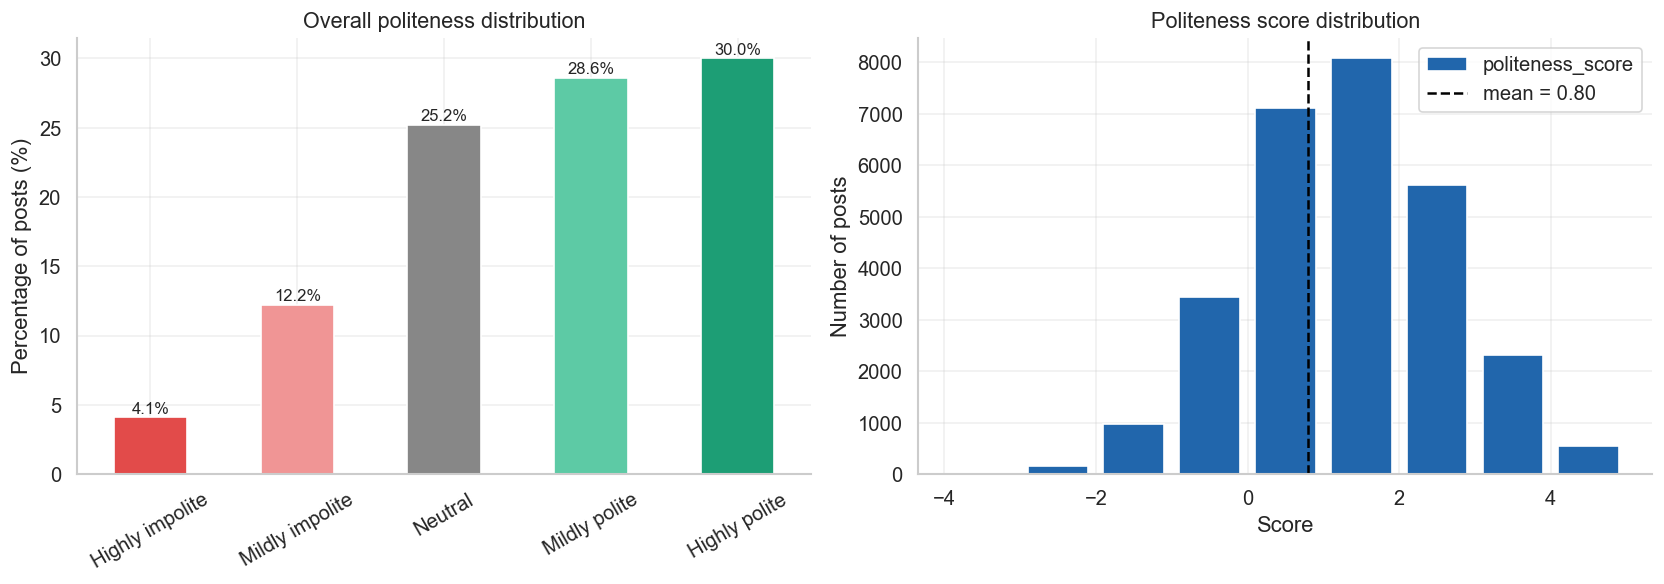

In [4]:
cat_colors = ['#E24B4A', '#F09595', '#878787', '#5DCAA5', '#1D9E75']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_pct.plot(kind='bar', ax=axes[0], color=cat_colors, edgecolor='white')
axes[0].set_title('Overall politeness distribution')
axes[0].set_ylabel('Percentage of posts (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cat_pct):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10)

df['politeness_score'].plot(kind='hist', bins=range(-4, 6), ax=axes[1],
                             color=BLUE, edgecolor='white', rwidth=0.8)
axes[1].axvline(df['politeness_score'].mean(), color='black', linestyle='--',
                label=f"mean = {df['politeness_score'].mean():.2f}")
axes[1].set_title('Politeness score distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Number of posts')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_overall_distribution.png')
plt.show()

## Politeness strategy profiles
Which specific strategies (please, gratitude, hedges etc.) are most common?

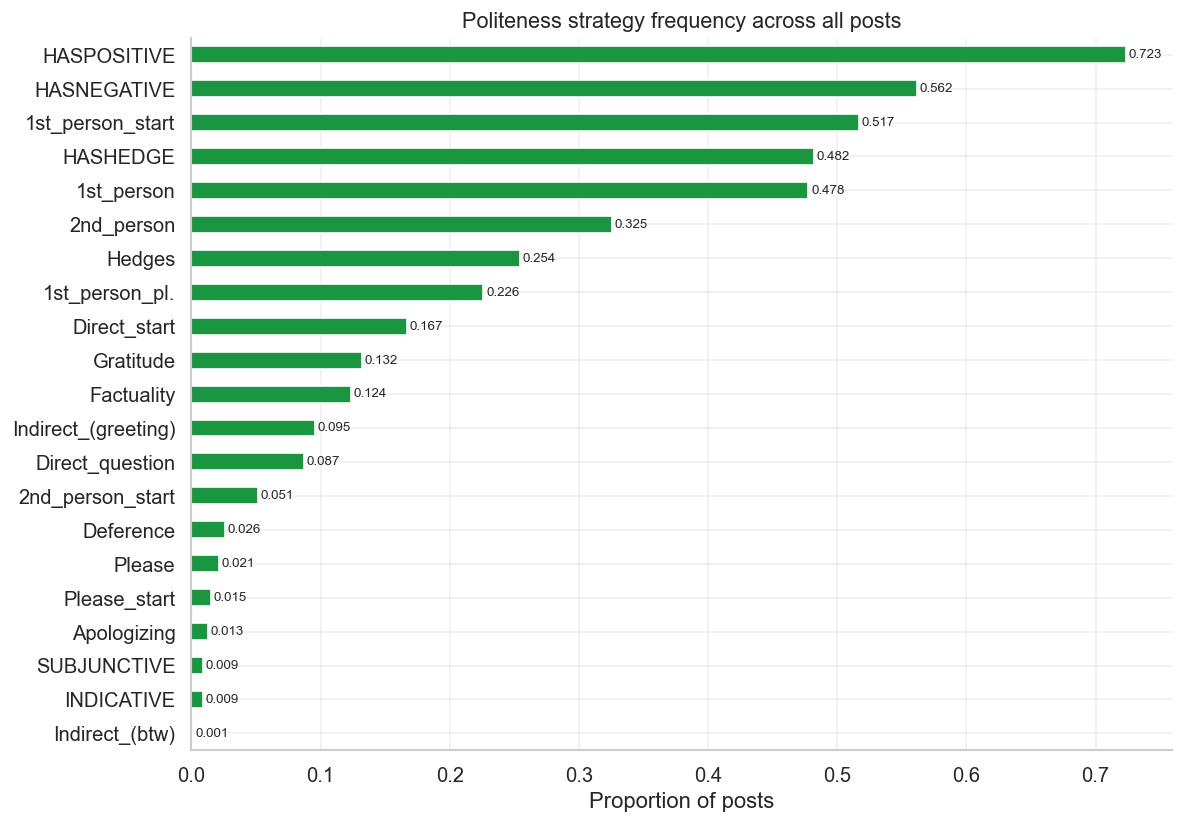

In [5]:
# strategy frequency across all posts
strategy_cols = [c for c in df.columns if 'feature_politeness' in c]
for col in strategy_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

strategy_means = df[strategy_cols].mean().sort_values()
strategy_means.index = (strategy_means.index
    .str.replace('feature_politeness_==', '')
    .str.replace('==', ''))

colors_strat = [GREEN if v > 0 else RED for v in strategy_means.values]

fig, ax = plt.subplots(figsize=(10, 7))
strategy_means.plot(kind='barh', ax=ax, color=colors_strat, edgecolor='white')
ax.set_title('Politeness strategy frequency across all posts')
ax.set_xlabel('Proportion of posts')

for bar in ax.patches:
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}',
            ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_strategy_profiles.png')
plt.show()

## 3. Politeness by post type
Comparing politeness scores across structural post types (Comment vs CommentThread) and content flags (question, answer, opinion).

In [6]:
print('Politeness by post_type:')
pt_stats = df.groupby('post_type')['politeness_score'].agg(['mean', 'median', 'std', 'count'])
print(pt_stats.round(3))

# Kruskal-Wallis test (non-parametric ANOVA appropriate for ordinal scores)
groups = [group['politeness_score'].values
          for _, group in df.groupby('post_type')]
if len(groups) >= 2:
    h_stat, p_val = kruskal(*groups)
    print(f'\nKruskal-Wallis H = {h_stat:.3f}, p = {p_val:.4f}')
    print('Significant difference across post types.' if p_val < 0.05
          else 'No significant difference across post types.')

Politeness by post_type:
                mean  median    std  count
post_type                                 
Comment        0.667     1.0  1.365  16061
CommentThread  0.968     1.0  1.322  12188

Kruskal-Wallis H = 337.207, p = 0.0000
Significant difference across post types.


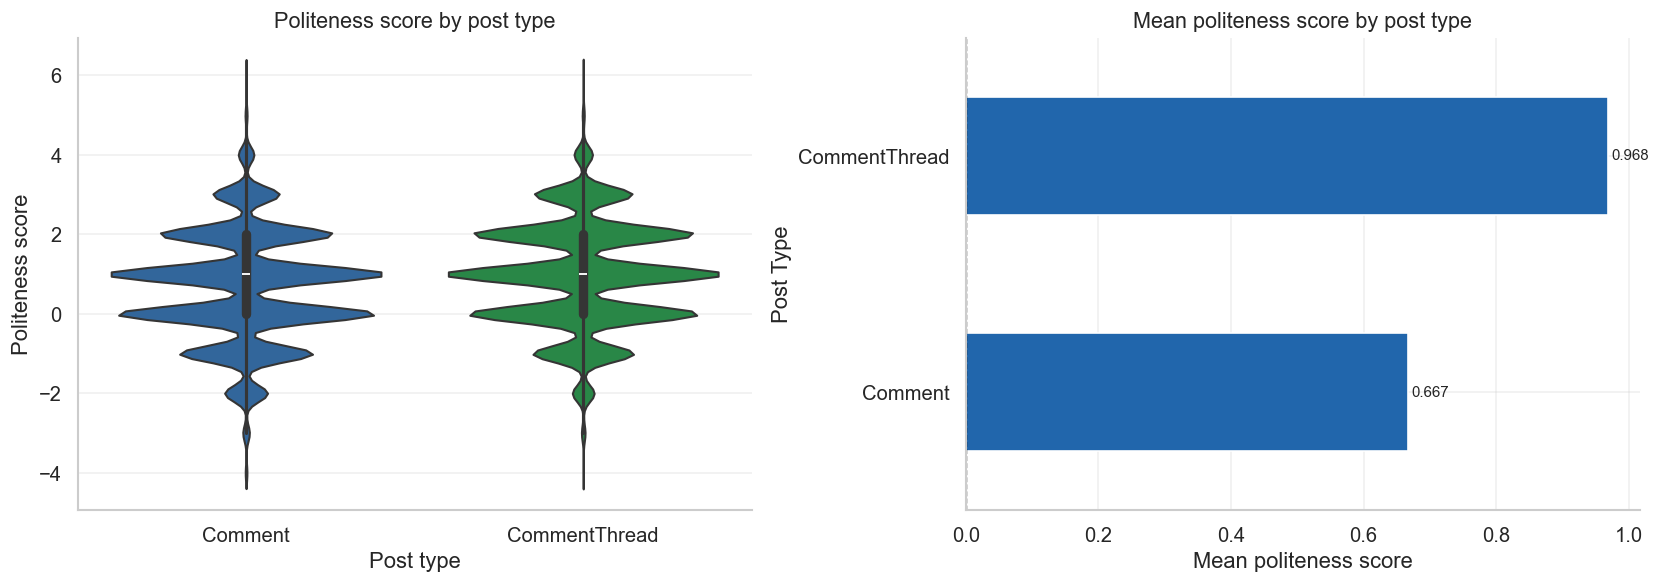

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='post_type', y='politeness_score',
               hue='post_type', palette=[BLUE, GREEN],
               ax=axes[0], inner='box', legend=False)
axes[0].set_title('Politeness score by post type')
axes[0].set_xlabel('Post type')
axes[0].set_ylabel('Politeness score')

pt_stats['mean'].sort_values().plot(kind='barh', ax=axes[1],
                                     color=BLUE, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Mean politeness score by post type')
axes[1].set_xlabel('Mean politeness score')
axes[1].set_ylabel('Post Type')

for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.3f}',
                 ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_politeness_by_posttype.png')
plt.show()

Question: not_question mean=0.835, question mean=0.654, p=0.0000
Answer: not_answer mean=0.904, answer mean=0.377, p=0.0000
Opinion: not_opinion mean=0.597, opinion mean=0.947, p=0.0000


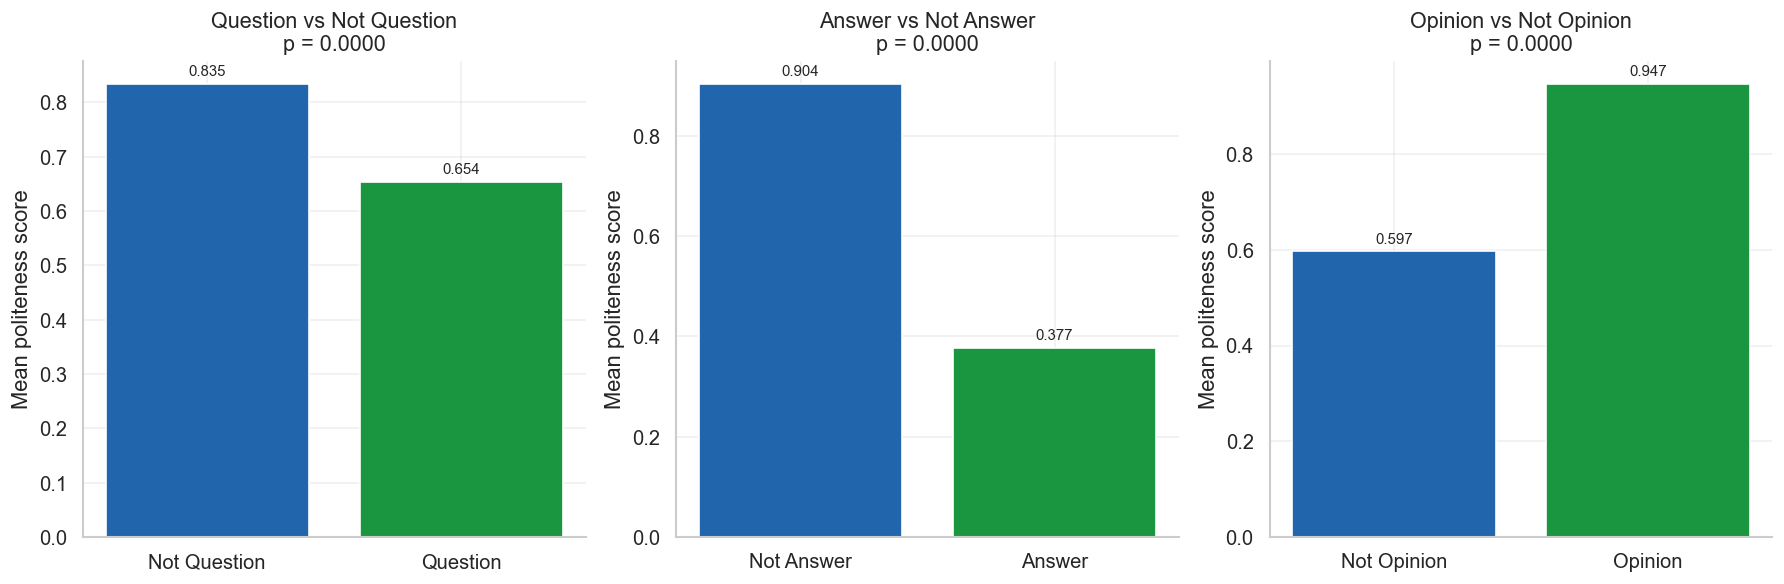

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, label in zip(axes,
                           ['is_question', 'is_answer', 'is_opinion'],
                           ['Question', 'Answer', 'Opinion']):
    g0 = df[df[col] == 0]['politeness_score'].values
    g1 = df[df[col] == 1]['politeness_score'].values
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')

    bars = ax.bar([f'Not {label}', label], [g0.mean(), g1.mean()],
                  color=[BLUE, GREEN], edgecolor='white')
    ax.set_title(f'{label} vs Not {label}\np = {p:.4f}')
    ax.set_ylabel('Mean politeness score')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    for bar, val in zip(bars, [g0.mean(), g1.mean()]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)

    print(f'{label}: not_{label.lower()} mean={g0.mean():.3f}, {label.lower()} mean={g1.mean():.3f}, p={p:.4f}')

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_politeness_by_flags.png')
plt.show()

## 4. Politeness correlations with continuous variables
How do sentiment, confusion, urgency, reads, and upvotes relate to politeness?

In [9]:
# Spearman correlations between politeness and continuous variables
continuous_vars = ['sentiment', 'confusion', 'urgency', 'up_count', 'reads', 'word_count']

print(f'{"Variable":<15} {"r":>8} {"p":>10}')
for var in continuous_vars:
    clean  = df[['politeness_score', var]].dropna()
    r, p   = spearmanr(clean['politeness_score'], clean[var])
    sig    = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{var:<15} {r:>8.3f} {p:>10.4f} {sig}')

Variable               r          p
sentiment          0.155     0.0000 ***
confusion         -0.050     0.0000 ***
urgency            0.019     0.0011 **
up_count           0.011     0.0633 
reads             -0.056     0.0000 ***
word_count         0.199     0.0000 ***


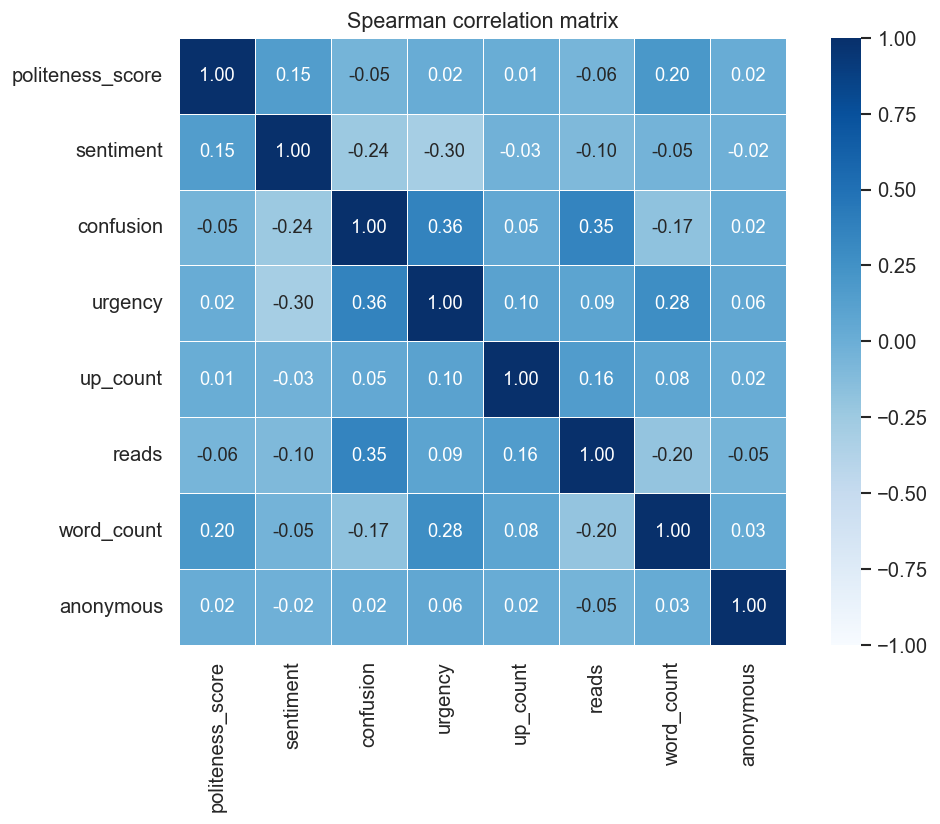

In [10]:
corr_cols = ['politeness_score', 'sentiment', 'confusion', 'urgency',
             'up_count', 'reads', 'word_count', 'anonymous']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(method='spearman'),
            annot=True, fmt='.2f', cmap='Blues',
            center=0, square=True, linewidths=0.5,
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Spearman correlation matrix')
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_correlation_matrix.png')
plt.show()

## 5. Politeness and anonymity
Are anonymous posts less polite? 

In [11]:
# anonymity effect on politeness
g0 = df[df['anonymous'] == 0]['politeness_score'].values
g1 = df[df['anonymous'] == 1]['politeness_score'].values

u, p = mannwhitneyu(g0, g1, alternative='two-sided')
r    = 1 - (2 * u) / (len(g0) * len(g1))

print(f'Non-anonymous mean : {g0.mean():.3f} (n={len(g0):,})')
print(f'Anonymous mean     : {g1.mean():.3f} (n={len(g1):,})')
print(f'Mann-Whitney p     : {p:.4f}')
print(f'Effect size r      : {r:.3f}')

Non-anonymous mean : 0.793 (n=27,758)
Anonymous mean     : 1.008 (n=508)
Mann-Whitney p     : 0.0008
Effect size r      : 0.085


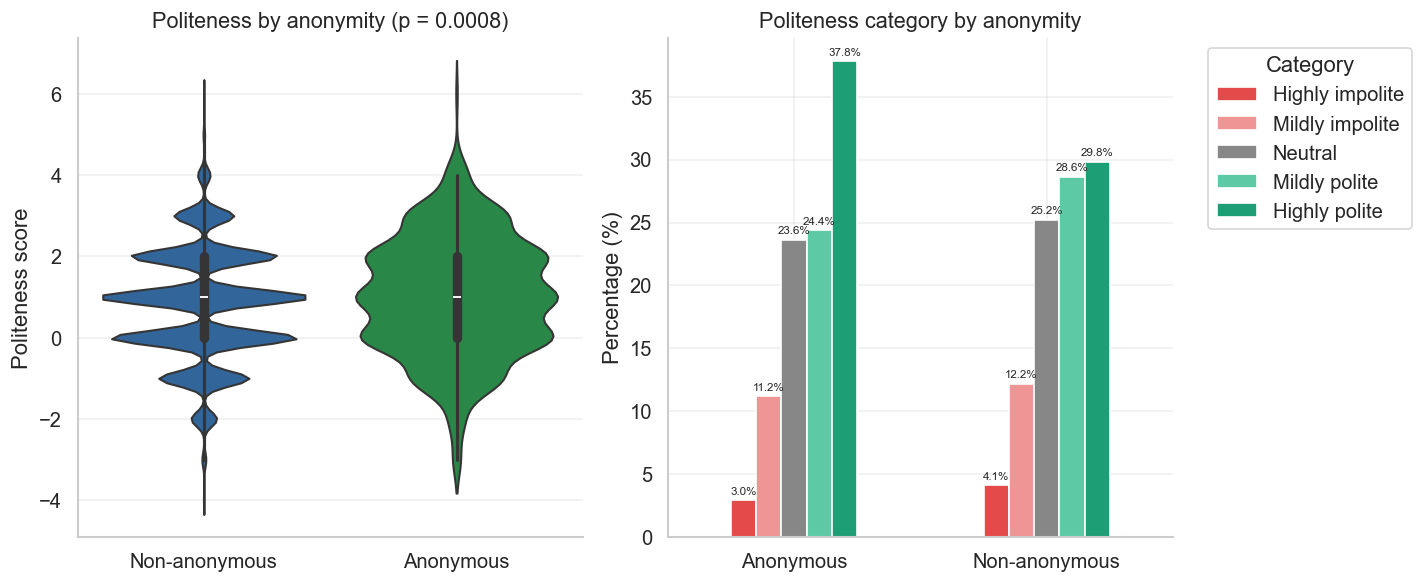

In [12]:
df['anonymous_label'] = df['anonymous'].map({0: 'Non-anonymous', 1: 'Anonymous'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df.dropna(subset=['anonymous_label']),
               x='anonymous_label', y='politeness_score',
               hue='anonymous_label', palette=[BLUE, GREEN],
               ax=axes[0], inner='box', legend=False)
axes[0].set_title(f'Politeness by anonymity (p = {p:.4f})')
axes[0].set_xlabel('')
axes[0].set_ylabel('Politeness score')

anon_cat = df.groupby(['anonymous_label', 'politeness_cat']).size().unstack(fill_value=0)
anon_cat_pct = anon_cat.div(anon_cat.sum(axis=1), axis=0) * 100
anon_cat_pct[cat_order].plot(kind='bar', ax=axes[1],
                              color=cat_colors, edgecolor='white')
axes[1].set_title('Politeness category by anonymity')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category', bbox_to_anchor=(1.05, 1))

for bar in axes[1].patches:
    height = bar.get_height()
    if height > 1:
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     height + 0.3,
                     f'{height:.1f}%',
                     ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_politeness_anonymity.png')
plt.show()


## 6. Politeness by course type
Does discipline (humanities, education, medicine) affect politeness?

In [13]:
# politeness by course discipline
ct_stats = df.groupby('course_type')['politeness_score'].agg(['mean', 'median', 'std', 'count'])
print(ct_stats.round(3).to_string())

groups = [g['politeness_score'].values for _, g in df.groupby('course_type') if len(g) > 30]
h, p   = kruskal(*groups)
print(f'\nKruskal-Wallis H = {h:.3f}, p = {p:.4f}')

              mean  median    std  count
course_type                             
Education    0.927     1.0  1.298   9592
Humanities   0.824     1.0  1.336   9300
Medicine     0.637     1.0  1.414   9372

Kruskal-Wallis H = 229.269, p = 0.0000


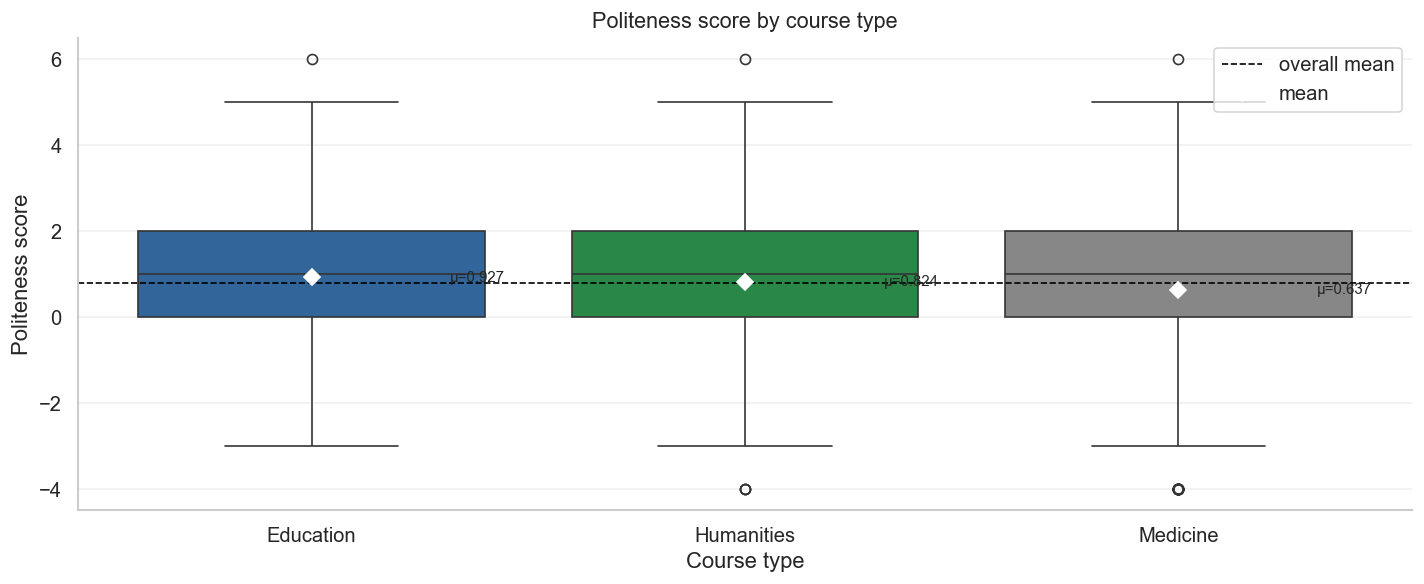

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

order = ct_stats['mean'].sort_values(ascending=False).index
sns.boxplot(data=df, x='course_type', y='politeness_score',
            order=order, hue='course_type',
            palette=[BLUE, GREEN, GREY], ax=ax, legend=False)
ax.axhline(df['politeness_score'].mean(), color='black',
           linestyle='--', linewidth=1, label='overall mean')

for i, course in enumerate(order):
    mean_val = ct_stats.loc[course, 'mean']
    ax.plot(i, mean_val, marker='D', color='white',
            markersize=7, zorder=5, label='mean' if i == 0 else '')
    ax.text(i + 0.32, mean_val,
            f'μ={mean_val:.3f}',
            va='center', fontsize=9)

ax.set_title('Politeness score by course type')
ax.set_xlabel('Course type')
ax.set_ylabel('Politeness score')
ax.tick_params(axis='x', rotation=0)
ax.legend()

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_politeness_by_coursetype.png')
plt.show()

## 7. Cross-tabulation by course discipline
Examining how post types and content flags are distributed across Medicine, Education and Humanities.

Content flags by discipline:
             % Question  % Answer  % Opinion
course_type                                 
Education           7.3       1.9       90.7
Humanities         22.0      18.1       39.6
Medicine           33.8      41.3       40.2

Post type by discipline:
post_type    Comment  CommentThread
course_type                        
Education       38.9           61.1
Humanities      59.5           40.5
Medicine        72.6           27.4

Kruskal-Wallis (question rate across disciplines): H = nan, p = nan


/var/folders/yn/c12lq2sn20j1_ny3nyjp3s0w0000gn/T/ipykernel_14475/2513284414.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  h, p   = kruskal(*groups)


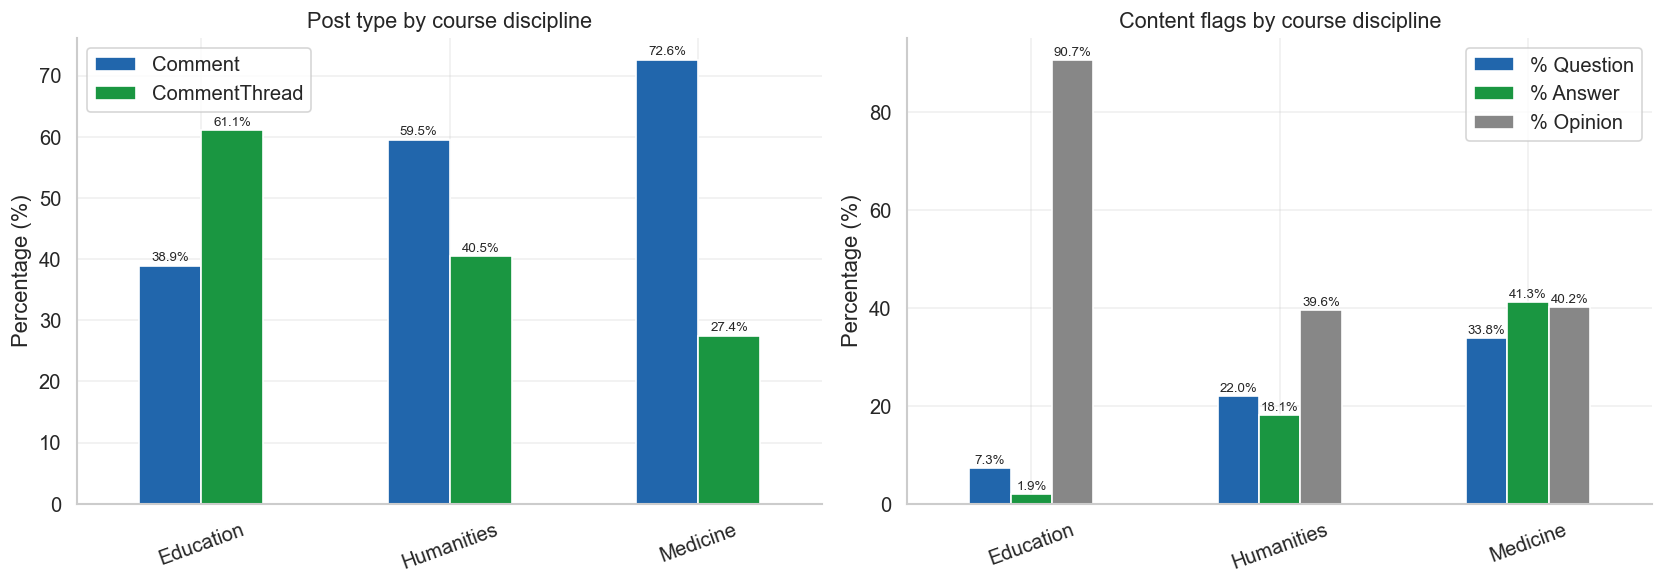

In [15]:
# cross-tabulation of post type and content flags by course discipline

for col in ['is_question', 'is_answer', 'is_opinion']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

flag_cols = ['is_question', 'is_answer', 'is_opinion']
flag_by_course = (df.groupby('course_type')[flag_cols].mean() * 100).round(1)
flag_by_course.columns = ['% Question', '% Answer', '% Opinion']

ct_pct = pd.crosstab(df['course_type'], df['post_type'], normalize='index') * 100

print('Content flags by discipline:')
print(flag_by_course.to_string())
print('\nPost type by discipline:')
print(ct_pct.round(1).to_string())

groups = [df[df['course_type'] == ct]['is_question'].dropna().values
          for ct in df['course_type'].unique()]
h, p   = kruskal(*groups)
print(f'\nKruskal-Wallis (question rate across disciplines): H = {h:.3f}, p = {p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_pct.plot(kind='bar', ax=axes[0], color=[BLUE, GREEN], edgecolor='white')
axes[0].set_title('Post type by course discipline')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=8)

flag_by_course.plot(kind='bar', ax=axes[1], color=[BLUE, GREEN, GREY], edgecolor='white')
axes[1].set_title('Content flags by course discipline')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_posttype_by_course.png')
plt.show()


## 8. Politeness by urgency and confusion levels
Do high-urgency or high-confusion posts tend to be less polite?

High urgency: low mean=0.772, high mean=0.817, p=0.0448
High confusion: low mean=0.865, high mean=0.762, p=0.0000


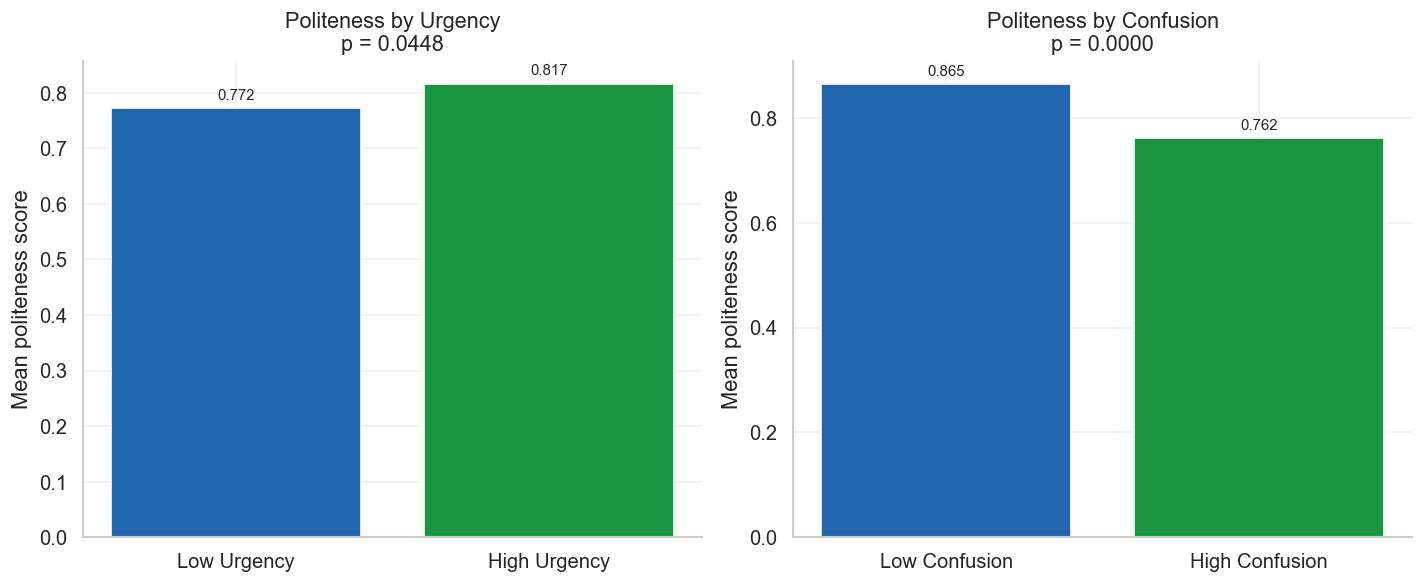

In [16]:
df['high_urgency']   = (df['urgency']   >= df['urgency'].median()).astype(int)
df['high_confusion'] = (df['confusion'] >= df['confusion'].median()).astype(int)

# politeness by urgency and confusion levels
for col, label in [('high_urgency', 'High urgency'), ('high_confusion', 'High confusion')]:
    g0 = df[df[col] == 0]['politeness_score'].values
    g1 = df[df[col] == 1]['politeness_score'].values
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')
    print(f'{label}: low mean={g0.mean():.3f}, high mean={g1.mean():.3f}, p={p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes,
                           ['high_urgency', 'high_confusion'],
                           ['Urgency', 'Confusion']):
    g0 = df[df[col] == 0]['politeness_score'].values
    g1 = df[df[col] == 1]['politeness_score'].values
    _, p = mannwhitneyu(g0, g1, alternative='two-sided')

    bars = ax.bar([f'Low {label}', f'High {label}'],
                  [g0.mean(), g1.mean()],
                  color=[BLUE, GREEN], edgecolor='white')
    ax.set_title(f'Politeness by {label}\np = {p:.4f}')
    ax.set_ylabel('Mean politeness score')
    ax.set_xlabel('')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    for bar, val in zip(bars, [g0.mean(), g1.mean()]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_politeness_by_urgency_confusion.png')
plt.show()

## 10. Top courses by politeness
Which courses have the most and least polite discussions?

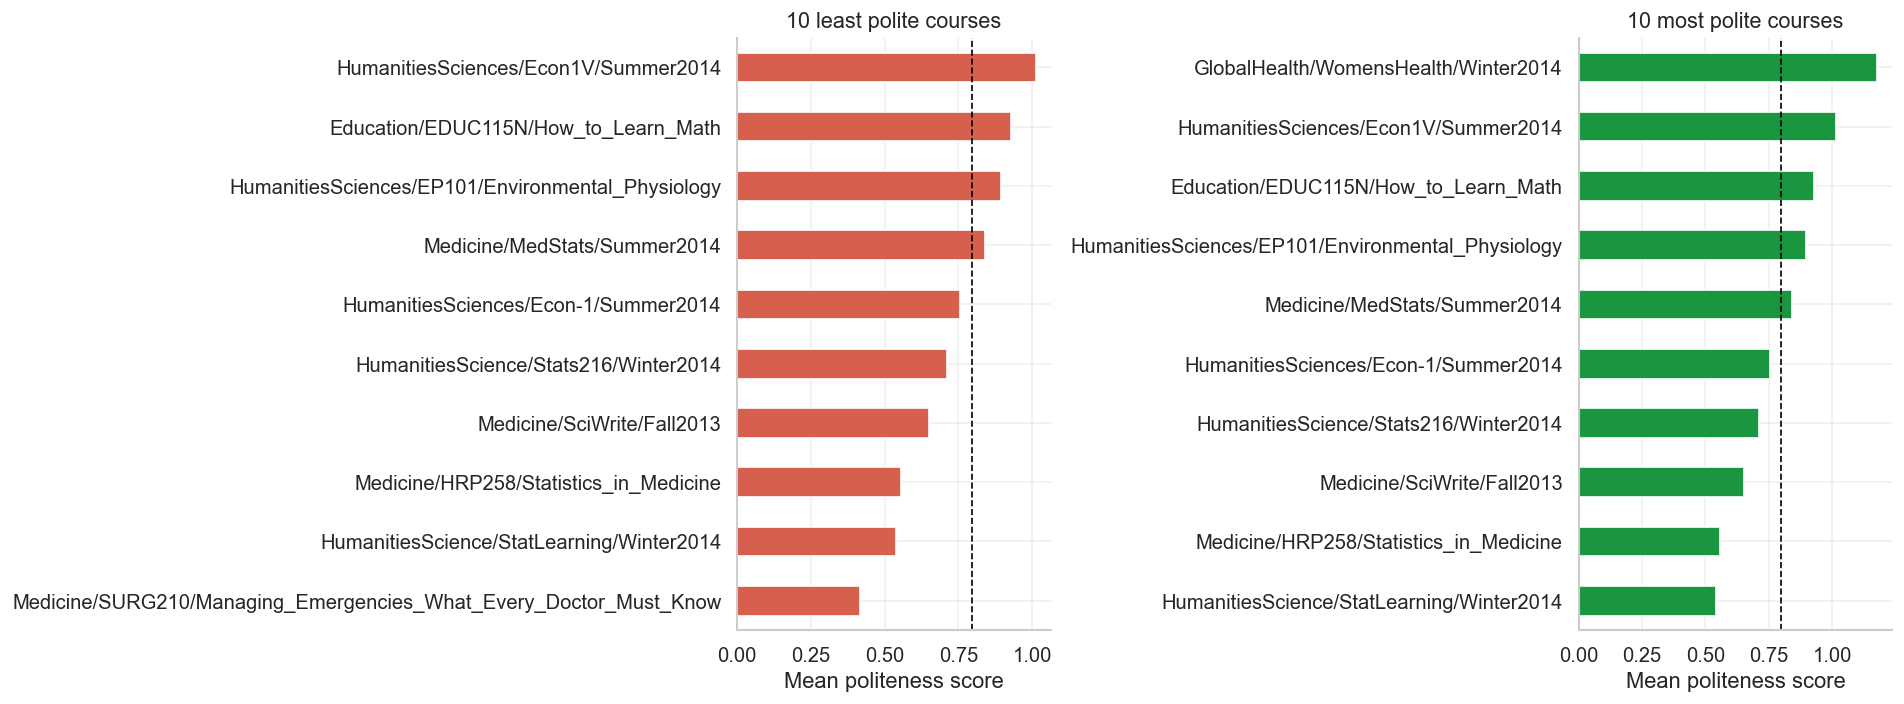

In [17]:
course_stats = (
    df.groupby('course_display_name')['politeness_score']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

course_stats.head(10)['mean'].plot(kind='barh', ax=axes[0], color=RED, edgecolor='white')
axes[0].set_title('10 least polite courses')
axes[0].set_xlabel('Mean politeness score')
axes[0].set_ylabel('')
axes[0].axvline(df['politeness_score'].mean(), color='black', linestyle='--', linewidth=1)

course_stats.tail(10)['mean'].plot(kind='barh', ax=axes[1], color=GREEN, edgecolor='white')
axes[1].set_title('10 most polite courses')
axes[1].set_xlabel('Mean politeness score')
axes[1].set_ylabel('')
axes[1].axvline(df['politeness_score'].mean(), color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_politeness_by_course.png')
plt.show()

In [18]:
# representative post per discipline
pd.set_option('display.max_colwidth', 300)

rep_posts = []
for discipline in ['Medicine', 'Humanities', 'Education']:
    sample = (df[df['course_type'] == discipline]
              .dropna(subset=['text_clean'])
              [['text_clean', 'course_type', 'post_type', 'politeness_score']]
              .sample(1, random_state=42)
              .reset_index(drop=True))
    rep_posts.append(sample)

rep_table = pd.concat(rep_posts).reset_index(drop=True)
rep_table.columns = ['Example Post', 'Discipline', 'Post Type', 'Politeness Score']
display(rep_table[['Discipline', 'Post Type', 'Politeness Score', 'Example Post']])
rep_table.to_csv(DATA_OUT / 'representative_posts.csv', index=False)
print('Saved to representative_posts.csv')

,Discipline,Post Type,Politeness Score,Example Post
0,Medicine,CommentThread,1,"I have been selected to review a well written essay, but the content is just a summary of an experimental technique. There are no experimental findings or references given, causing me to question how this addresses the prompt. I thoroughly enjoyed reading the essay and want to give feedback, but..."
1,Humanities,Comment,2,"Violence by a man against woman is less about individuals but more a reflection of deeply ingrained cultural mores about power, gender roles, and household composition. Historically, men have been given social permission to act out violently as a means of maintaining their status within the home..."
2,Education,Comment,1,"Hi, I have the same issue. I was answering question in second session, I have by accident copied wrong text (not even in English) to the response box and didn t even hit \submit\"". Now it would not let me to either edit or delete the wrong entry. It would be very helpful if someone could give an..."


Saved to representative_posts.csv


In [19]:
# save analysis dataset

for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = df[col].astype(str)

df.to_parquet(DATA_PROCESSED / 'posts_analysis.parquet', index=False)
print(f'Saved {len(df):,} posts to posts_analysis.parquet')

Saved 28,266 posts to posts_analysis.parquet
